In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import pandas as pd
import pickle
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from mpl_toolkits.mplot3d import Axes3D  


In [ ]:
rawdata = loadmat('./monkeydata.mat')
data = rawdata['trial']
# Data that we will use. (98 neurons, neural recording: spike).
# First index: trial number, Second index: direction, Third index: data type (0=trialID, 1=spikes, 2=handPos)
data.shape, data[0][0][1].shape    # 100 trials for 8 directions

((100, 8), (98, 672))

# Load “monkeydata.mat” including a dictionary data and calculate the number of spikes within an 100 ms sliding time window for 98 neurons.

In [5]:
def get_spike_from_window_size(data, w_start, w_end):
    '''
    params
    ------
    data : ndarray
        It has 800 data (100 trials * 8 directions)
    w_start : int
        start number of window
    w_end : int
        end number of window
    
    return
    ------
    num_spikes : ndarray ((w_end-w_start)*8, 98)
        It has total number of spikes in it
    target : ndarray ((w_end-w_start)*8)
    '''
    X = []
    y = []
    for trials in data:
        for target, trial in enumerate(trials):
            trial_number = trial[0]
            spike_timing = trial[1]
            hand_pos = trial[2]
            
            X.append(np.sum(spike_timing[:, w_start:w_end], axis=1))
            y.append(target)
    
    num_spikes = np.array(X)
    target = np.array(y)
            
    return num_spikes, target

In [49]:
time_window = 100
time_list = []
time_range = range(0, 600, time_window)

for a in time_range:
    time_list.append((a, a+100))

time_list

[(0, 100), (100, 200), (200, 300), (300, 400), (400, 500), (500, 600)]

In [50]:
num_spikes_list = []
target_list = []

for time in time_list:
    num_spikes, target = get_spike_from_window_size(data, time[0], time[1])
    num_spikes_list.append(num_spikes)
    target_list.append(target)

for i in range(len(target_list)):
    print(f'{time_list[i][0]}-{time_list[i][1]-1}: {np.sum(num_spikes_list[i])}')

0-99: 78601
100-199: 108921
200-299: 172209
300-399: 189737
400-499: 194750
500-599: 140177


# PCA

In [51]:
def plot_2PC(window, spike_pca, y):
    df = pd.DataFrame(spike_pca, columns=['PC1', 'PC2'])
    df['angles'] = y
    df['angles'] = pd.to_numeric(df['angles'])

    sns.lmplot(x='PC1', y='PC2', data=df, hue='angles', fit_reg=False, height=6, aspect=1.2)
    ax = plt.gca()
    ax.set_title(f"Two Principal Components: {window} ~ {window+100}ms",fontsize=15)
    plt.show()

spike_pca_list = []
for i, window in enumerate(time_range):
    pca = PCA(n_components=3)
    spike_array = num_spikes_list[i]
    mean = np.mean(num_spikes_list[i], axis=0)
    spike_array = num_spikes_list[i] - mean
    y = target_list[i]
    pca.fit(spike_array)
    spike_pca = pca.transform(spike_array)
    spike_pca_list.append(spike_pca)
    # plot_2PC(window, spike_pca, y)
spike_pca_traj = np.stack(spike_pca_list, axis=1)


# Explained variance

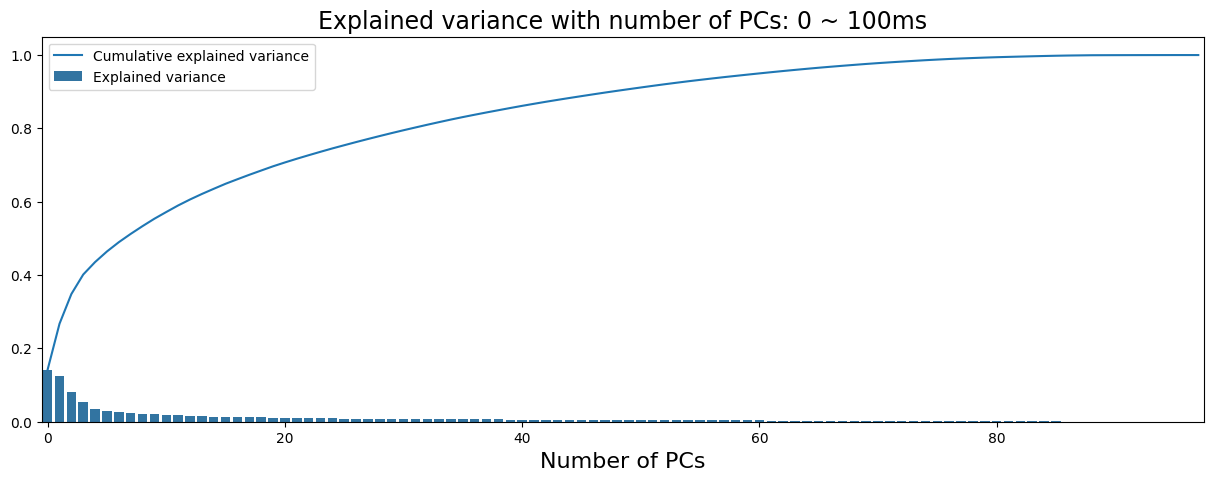

<<The fraction of explained variance by the first three PCs>>
PC 1: 0.1423866847629243
PC 2: 0.12486827559343171
PC 3: 0.08102693148886819


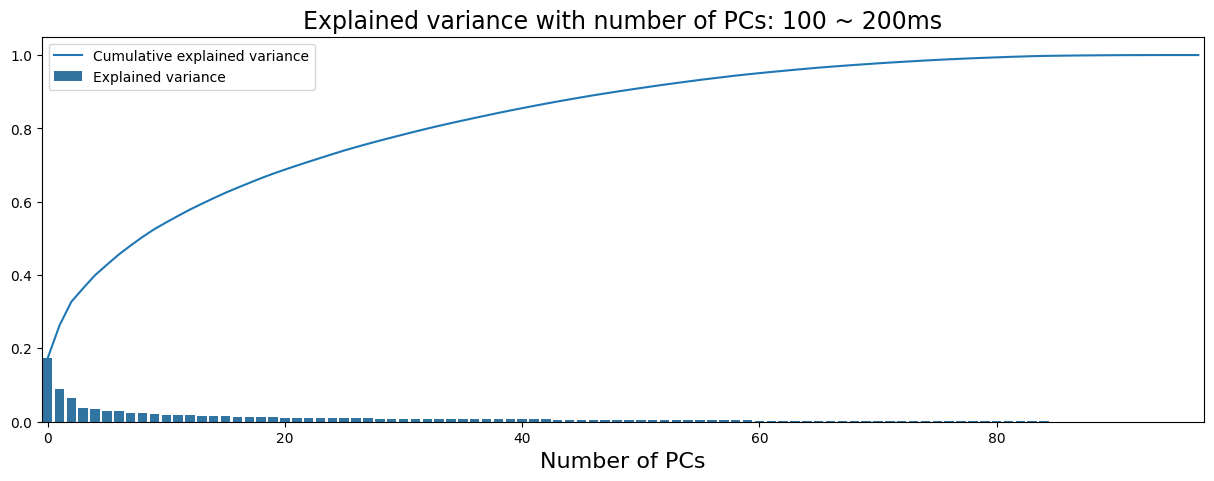

<<The fraction of explained variance by the first three PCs>>
PC 1: 0.1730807277376925
PC 2: 0.08956340590562002
PC 3: 0.06468747633234705


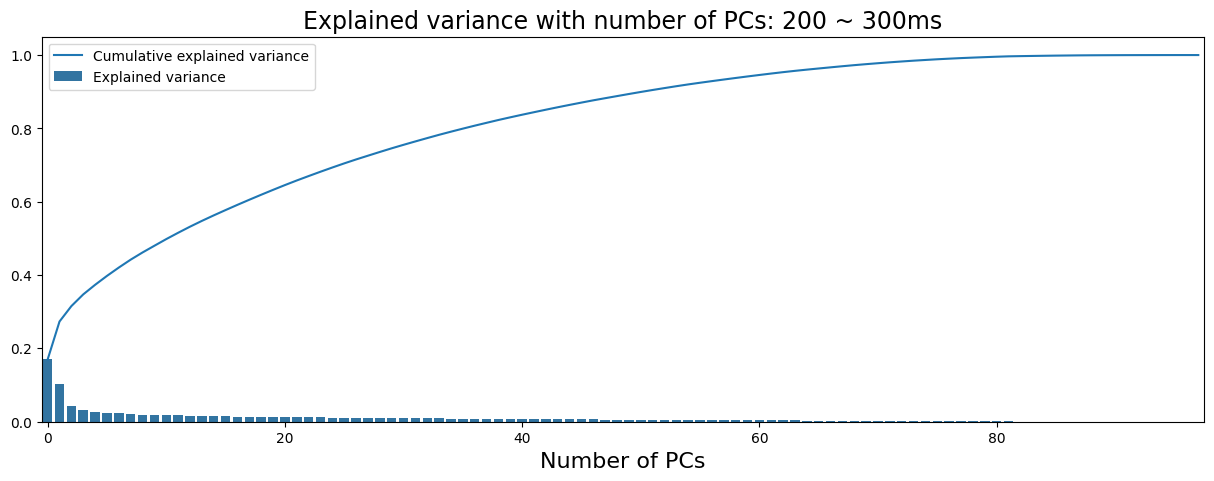

<<The fraction of explained variance by the first three PCs>>
PC 1: 0.16984053045870257
PC 2: 0.10348236508223035
PC 3: 0.042001500701162195


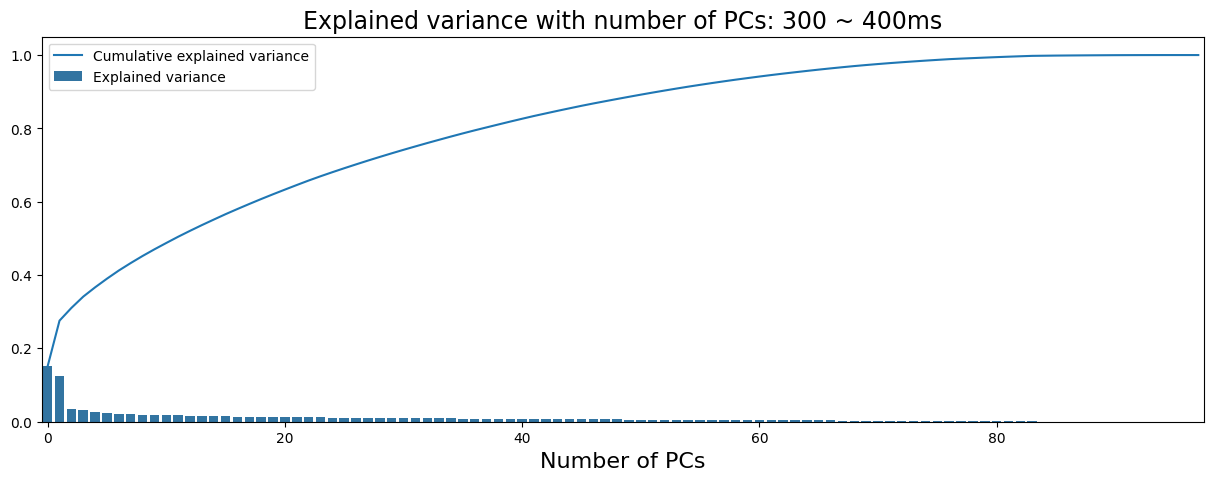

<<The fraction of explained variance by the first three PCs>>
PC 1: 0.15138765255573922
PC 2: 0.1242587667208689
PC 3: 0.034672993052945175


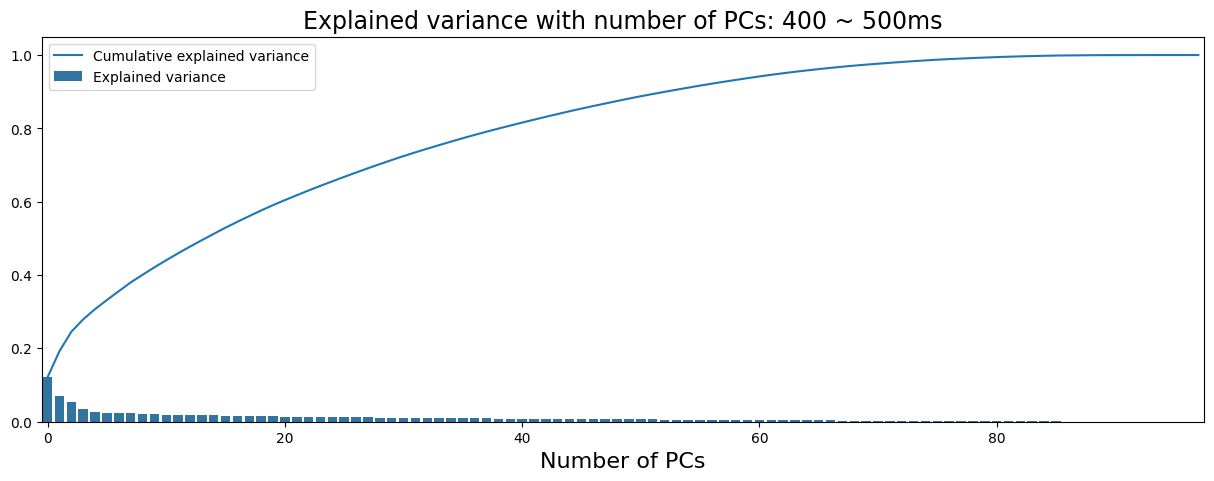

<<The fraction of explained variance by the first three PCs>>
PC 1: 0.1219347515029572
PC 2: 0.07080863565600459
PC 3: 0.05279413020286287


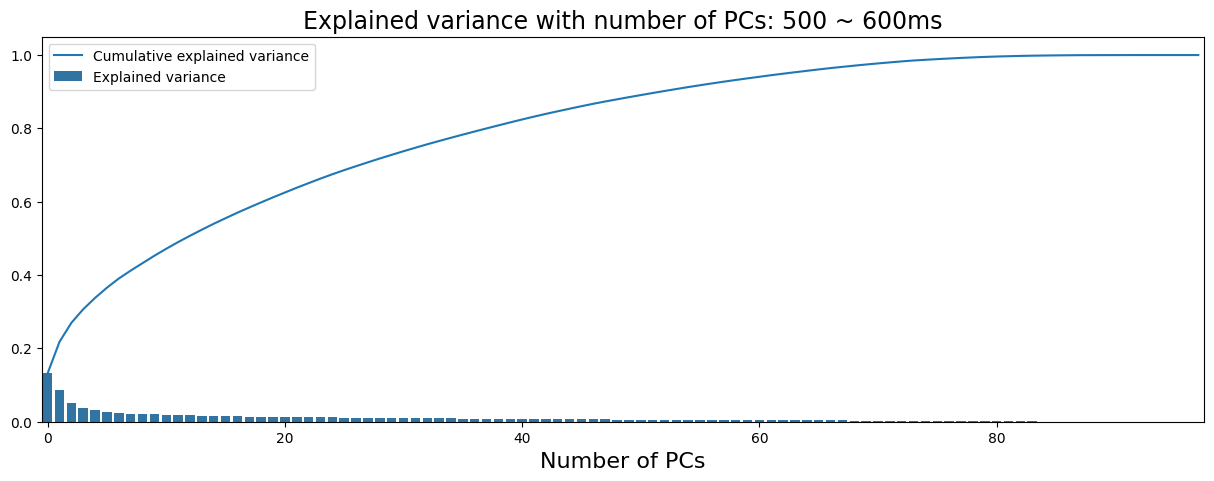

<<The fraction of explained variance by the first three PCs>>
PC 1: 0.13221571462364523
PC 2: 0.08575325291166734
PC 3: 0.051789694556524


In [53]:
def plot_exp_var(window, exp_var):
    sum_exp_var = np.cumsum(exp_var)
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))
    ax = sns.lineplot(data=sum_exp_var, label='Cumulative explained variance')
    ax = sns.barplot(x=np.arange(0,98), y=exp_var, label='Explained variance')
    ax.set_xticks(np.arange(0, 98, 20))
    plt.title(f"Explained variance with number of PCs: {window} ~ {window+100}ms",fontsize=17)
    plt.xlabel('Number of PCs',fontsize=16)
    plt.legend()
    plt.show()
    
    print('<<The fraction of explained variance by the first three PCs>>')
    for pc in range(3):
        print(f'PC {pc+1}: {exp_var[pc]}')

for i, window in enumerate(time_range):
    pca = PCA()
    spike_array = num_spikes_list[i]
    mean = np.mean(num_spikes_list[i], axis=0)
    spike_array = num_spikes_list[i] - mean
    y = target_list[i]
    pca.fit(spike_array)
    spike_pca = pca.transform(spike_array)
    
    ### plot
    exp_var = pca.explained_variance_ratio_
    plot_exp_var(window, exp_var)

# Clustering

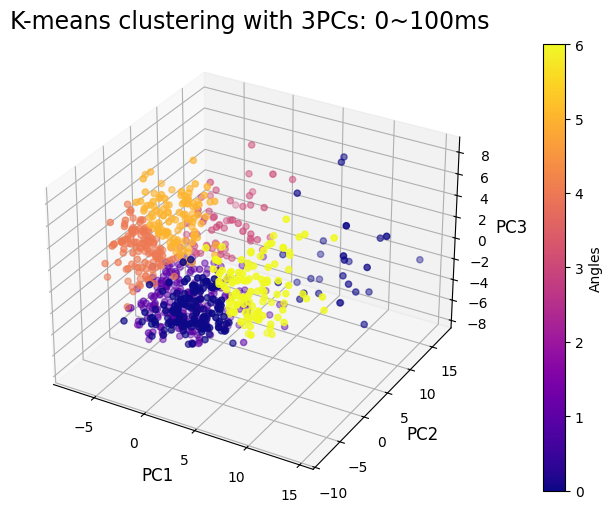

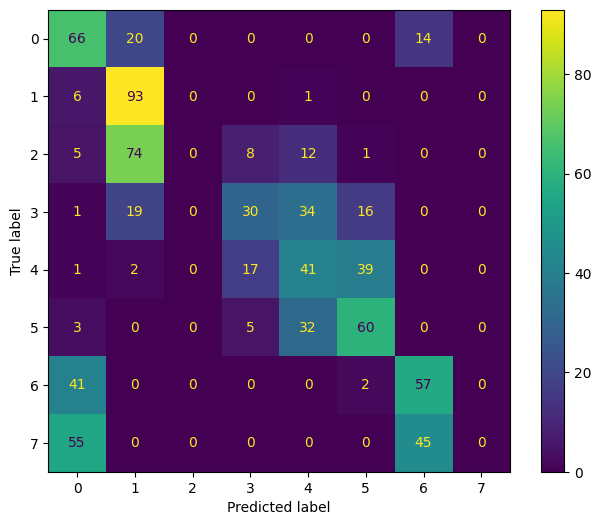

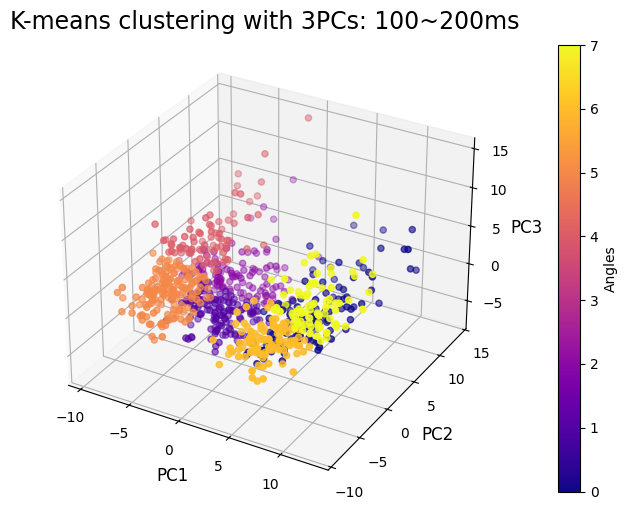

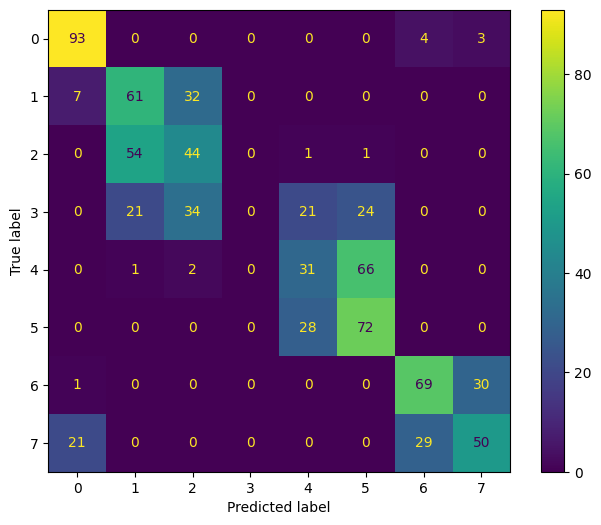

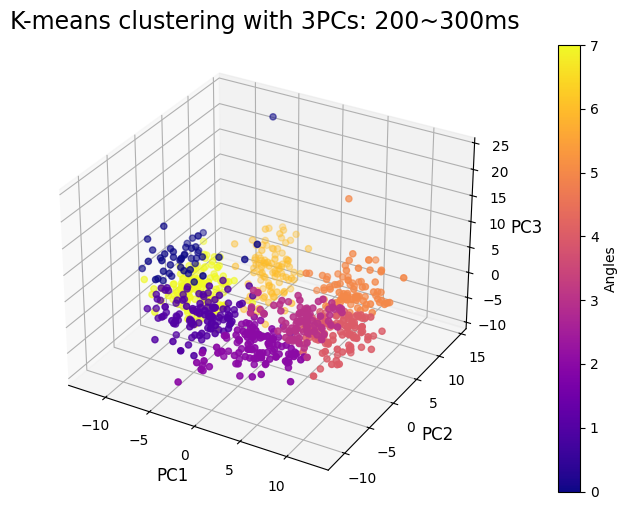

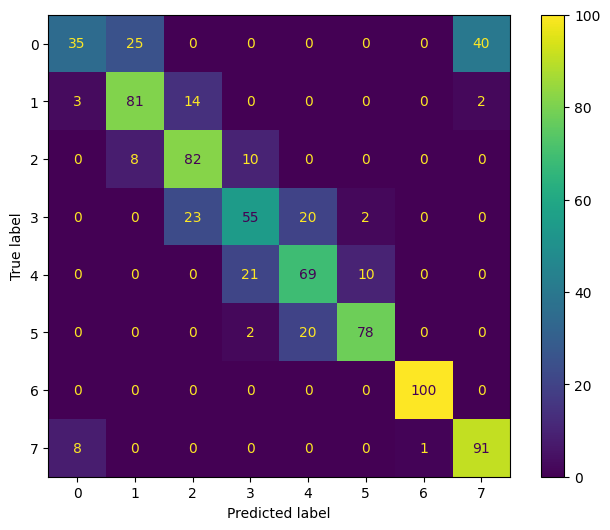

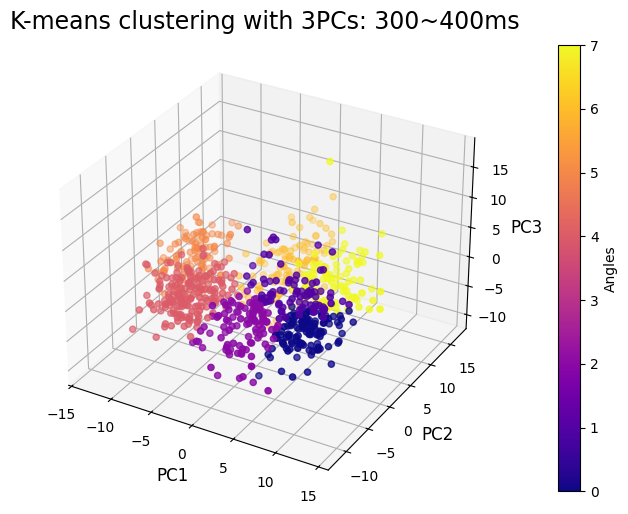

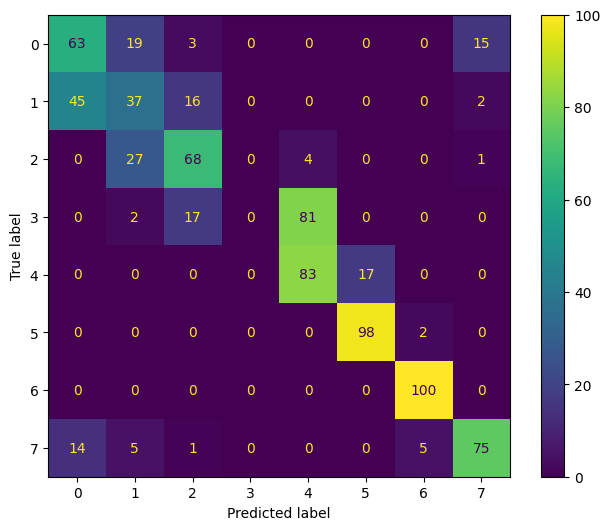

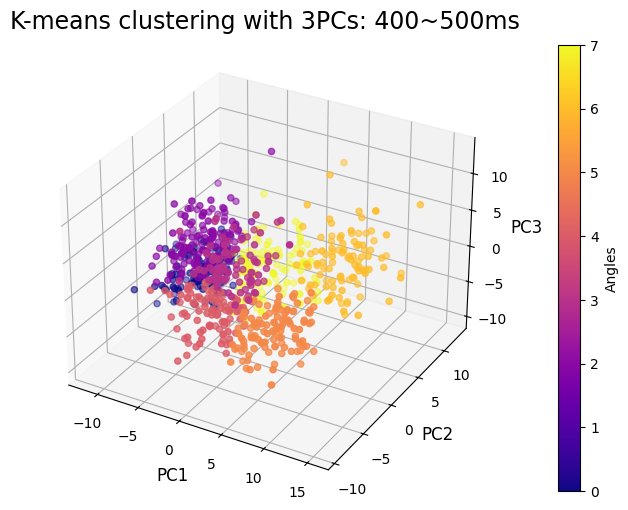

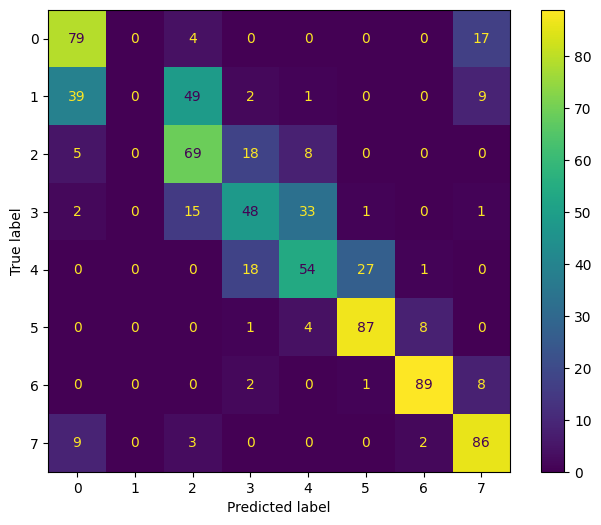

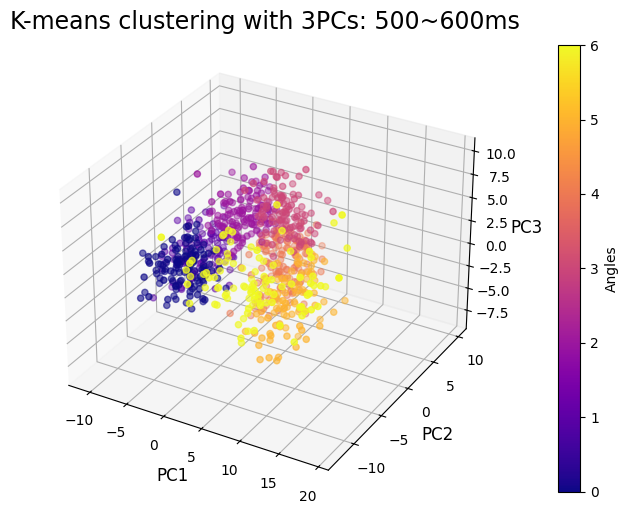

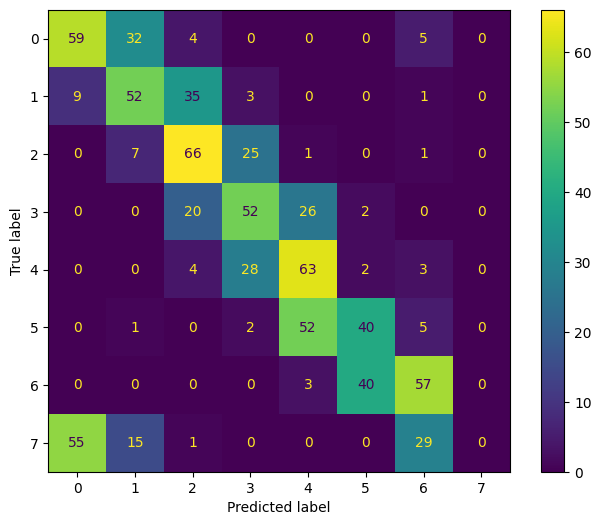

In [54]:
def plot_KMeans(window, spike_pca, y):
    est = KMeans(n_clusters=8)
    est.fit(spike_pca)
    labels_init = est.labels_
    
    # Match label IDs between PCA and the clustering algorithm
    labels = np.zeros_like(labels_init)
    for c in range(8):
        mask = (labels_init == c)
        labels[mask] = mode(y[mask])[0]
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(spike_pca[:, 0], spike_pca[:, 1], spike_pca[:, 2], c=labels.astype(float), cmap='plasma')

    # Add axis labels
    ax.set_xlabel("PC1", fontsize=12)
    ax.set_ylabel("PC2", fontsize=12)
    ax.set_zlabel("PC3", fontsize=12)
    ax.set_title(f"K-means clustering with 3PCs: {window}~{window+100}ms", fontsize=17)

    # Add color bar
    cbar = fig.colorbar(scatter, ax=ax, fraction=0.036, pad=0.1)
    cbar.set_label('Angles')
    plt.show()
    
    return labels

def plot_confusion_matrix(labels, y):
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y, labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    plt.show()
    return cm

cm_list = []
for i, window in enumerate(time_range):
    pca = PCA(n_components=3)
    spike_array = num_spikes_list[i]
    mean = np.mean(num_spikes_list[i], axis=0)
    spike_array = num_spikes_list[i] - mean
    y = target_list[i]
    pca.fit(spike_array)
    spike_pca = pca.transform(spike_array)
    
    labels = plot_KMeans(window, spike_pca, y)
    cm_list.append(plot_confusion_matrix(labels, y))

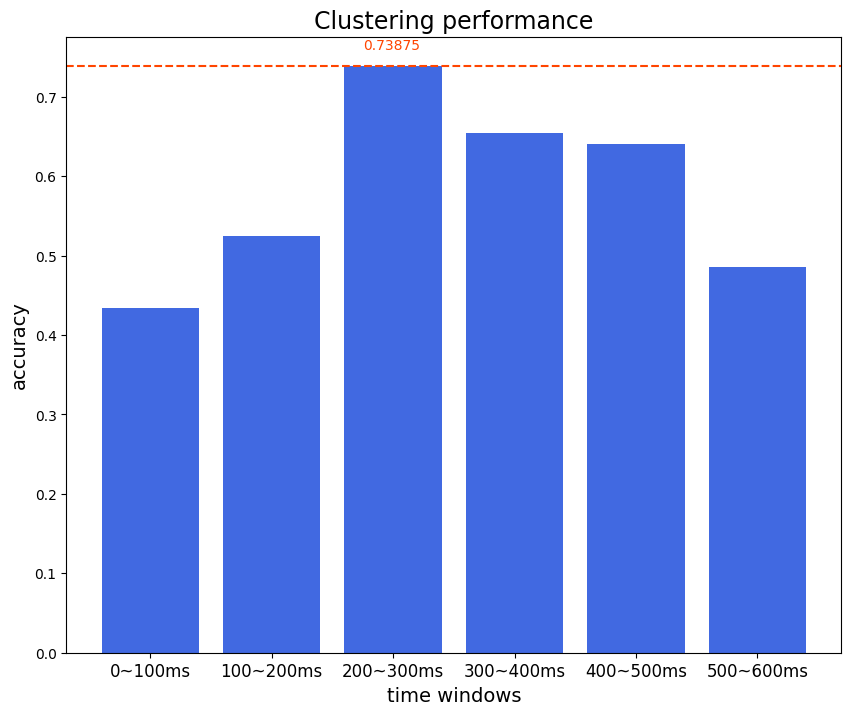

In [55]:
### Get clustering performance across different time windows
clustering_acc = []

for w, cm in enumerate(cm_list):
    total = np.sum(cm)
    correct = np.sum(np.diag(cm))
    acc = correct/total
    clustering_acc.append(acc)
    
### Plot clustering performance across different time windows
x = np.arange(len(time_range))
plt.figure(figsize=(10, 8))
plt.bar(x, clustering_acc, color='royalblue')
xticks = []
for w in time_range:
    xticks.append(f'{w}~{w+100}ms')
plt.xticks(x, labels=xticks, fontsize=12)
plt.axhline(max(clustering_acc), color='orangered', linestyle='--',)
plt.text(1.75, 0.76, f'{max(clustering_acc)}', color='orangered')
plt.title('Clustering performance', fontsize=17)
plt.xlabel('time windows', fontsize=14)
plt.ylabel('accuracy', fontsize=14)
plt.show()

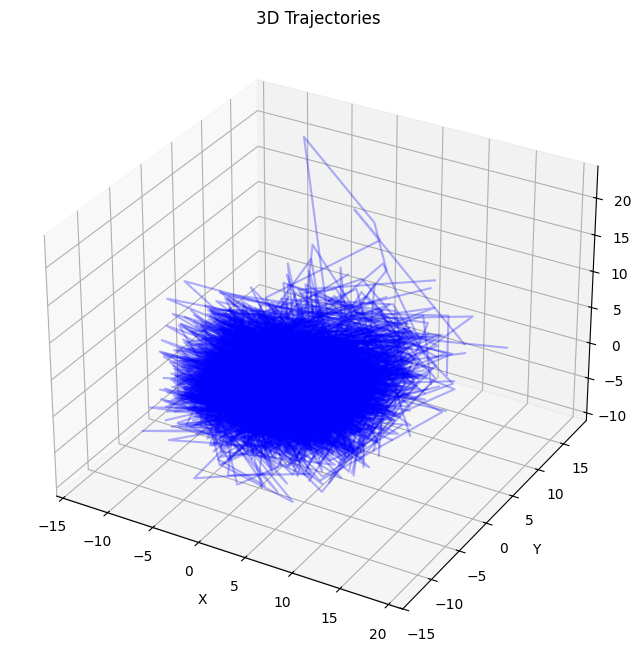

In [56]:
## 3D Trajectory plot of PCA results
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for traj in spike_pca_traj:
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], alpha=0.3, color='blue')  # alpha로 투명도 조절 가능

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Trajectories')
plt.show()
